In [1]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import pandas as pd

In [2]:
# Define class names
class_names = ["AI","REAL"]
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}
nb_classes = len(class_names)

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

In [3]:
# Define transformations (data preprocessing)
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
# Load datasets
train_dataset = datasets.ImageFolder(root=r"C:\Users\FAIZ\Music\ai image  real-20260203T051943Z-3-001\ai image  real\train", transform=transform)
test_dataset = datasets.ImageFolder(root=r"C:\Users\FAIZ\Music\ai image  real-20260203T051943Z-3-001\ai image  real\test", transform=transform)


In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
# Check dataset size
n_train = len(train_dataset)
n_test = len(test_dataset)

print(f"Number of training examples: {n_train}")
print(f"Number of testing examples: {n_test}")
print(f"Each image is of size: {IMAGE_SIZE}")

Number of training examples: 974
Number of testing examples: 974
Each image is of size: (150, 150)


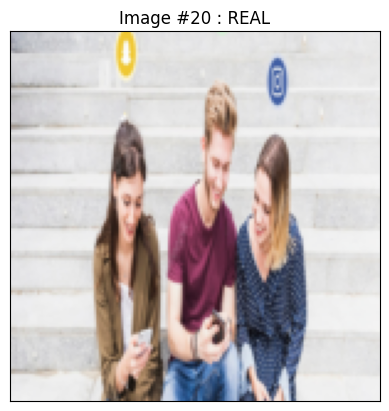

In [8]:
# Visualizing the dataset
def display_random_image(loader, class_names):
    """
    Display a random image from the dataset and its corresponding label.
    """
    # Get a batch of data
    dataiter = iter(loader)
    images, labels = next(dataiter)  # Use Python's built-in next() function
    
    index = np.random.randint(len(labels))  # Get a random index
    image = images[index].numpy().transpose(1, 2, 0)  # Transpose for correct display
    
    # Unnormalize the image for correct visualization (reverse of normalization)
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  
    image = np.clip(image, 0, 1)  # Clip to ensure valid pixel range
    
    plt.figure()
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f'Image #{index} : {class_names[labels[index]]}')
    plt.show()

# Call the function
display_random_image(train_loader, class_names)


C:\Users\FAIZ\anaconda3\envs\project\lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


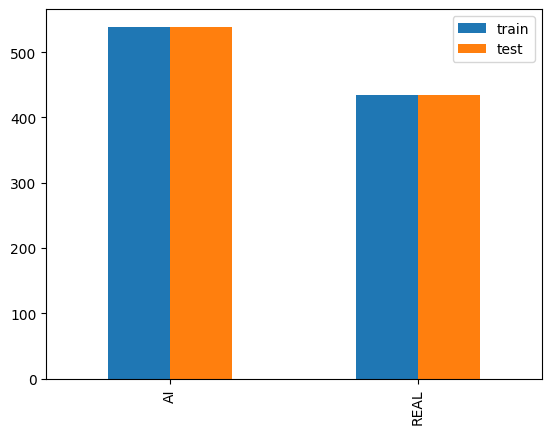

In [9]:
# Plotting dataset distribution
train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]
_, train_counts = np.unique(train_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)
pd.DataFrame({'train': train_counts,
              'test': test_counts}, index=class_names).plot.bar()
plt.show()

In [10]:
def display_examples(class_names, loader):
    num_examples = 30
    dataiter = iter(loader)
    images, labels = next(dataiter)

    plt.figure(figsize=(10, 10))
    for i in range(min(num_examples, len(images))):
        plt.subplot(6, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        
        # Convert tensor to numpy and clip values to [0, 1] range for imshow
        image = images[i].numpy().transpose(1, 2, 0)
        image = np.clip(image, 0, 1)  # Clipping values to the valid range
        
        plt.imshow(image)
        plt.xlabel(class_names[labels[i].item()])
    plt.show()


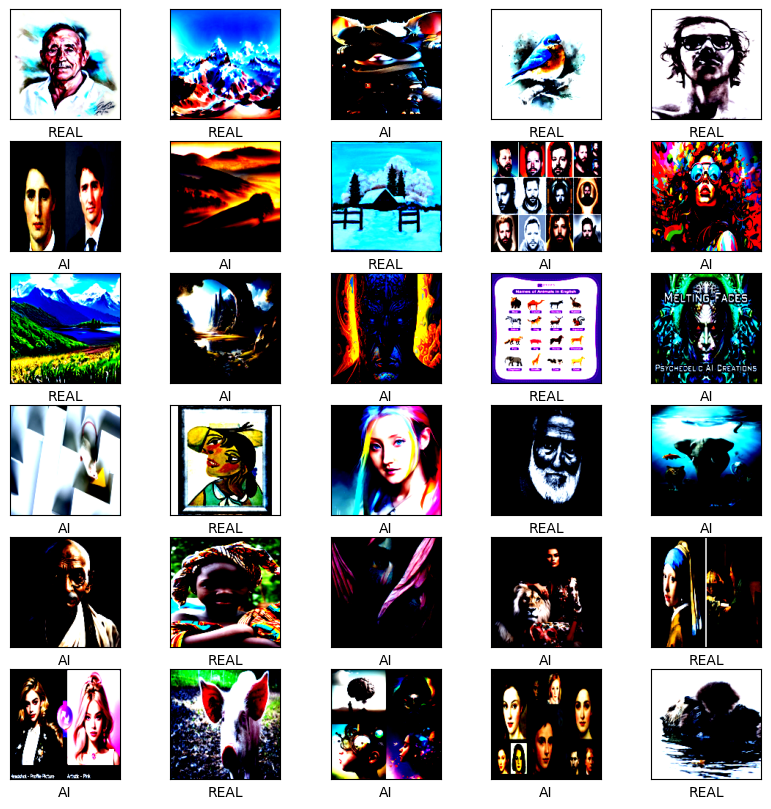

In [11]:
display_examples(class_names, train_loader)

100.0%
100.0%
100.0%
100.0%


Epoch [0/30], Step [200/600], d_loss: 0.3605, g_loss: 1.9106, Real Score: 0.9207, Fake Score: 0.2361
Epoch [0/30], Step [400/600], d_loss: 0.1377, g_loss: 3.9158, Real Score: 0.9665, Fake Score: 0.0955
Epoch [0/30], Step [600/600], d_loss: 0.9240, g_loss: 2.1424, Real Score: 0.6899, Fake Score: 0.2894
Epoch [1/30], Step [200/600], d_loss: 0.0738, g_loss: 4.3404, Real Score: 0.9784, Fake Score: 0.0489
Epoch [1/30], Step [400/600], d_loss: 0.9574, g_loss: 2.0644, Real Score: 0.6651, Fake Score: 0.2010
Epoch [1/30], Step [600/600], d_loss: 0.3525, g_loss: 2.8653, Real Score: 0.9120, Fake Score: 0.1870
Epoch [2/30], Step [200/600], d_loss: 0.2692, g_loss: 3.0711, Real Score: 0.9346, Fake Score: 0.1403
Epoch [2/30], Step [400/600], d_loss: 0.3118, g_loss: 3.4481, Real Score: 0.9214, Fake Score: 0.1314
Epoch [2/30], Step [600/600], d_loss: 0.2544, g_loss: 3.5120, Real Score: 0.8772, Fake Score: 0.0523
Epoch [3/30], Step [200/600], d_loss: 0.2352, g_loss: 4.0571, Real Score: 0.9355, Fake Scor

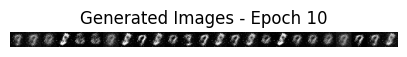

Epoch [10/30], Step [200/600], d_loss: 0.2325, g_loss: 3.1963, Real Score: 0.9180, Fake Score: 0.0622
Epoch [10/30], Step [400/600], d_loss: 0.3783, g_loss: 3.2424, Real Score: 0.8857, Fake Score: 0.1293
Epoch [10/30], Step [600/600], d_loss: 0.2663, g_loss: 4.7297, Real Score: 0.9656, Fake Score: 0.1522
Epoch [11/30], Step [200/600], d_loss: 0.6145, g_loss: 3.9661, Real Score: 0.9369, Fake Score: 0.3589
Epoch [11/30], Step [400/600], d_loss: 0.3472, g_loss: 4.6013, Real Score: 0.8891, Fake Score: 0.0603
Epoch [11/30], Step [600/600], d_loss: 0.3440, g_loss: 3.4628, Real Score: 0.9160, Fake Score: 0.1190
Epoch [12/30], Step [200/600], d_loss: 0.2550, g_loss: 4.0569, Real Score: 0.9559, Fake Score: 0.1370
Epoch [12/30], Step [400/600], d_loss: 0.5050, g_loss: 2.9949, Real Score: 0.8603, Fake Score: 0.1301
Epoch [12/30], Step [600/600], d_loss: 0.4051, g_loss: 3.1834, Real Score: 0.9395, Fake Score: 0.1986
Epoch [13/30], Step [200/600], d_loss: 0.4582, g_loss: 2.4731, Real Score: 0.9321,

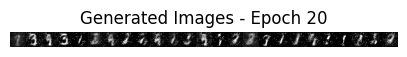

Epoch [20/30], Step [200/600], d_loss: 0.1418, g_loss: 5.4896, Real Score: 0.9325, Fake Score: 0.0225
Epoch [20/30], Step [400/600], d_loss: 0.5320, g_loss: 4.0028, Real Score: 0.9754, Fake Score: 0.2781
Epoch [20/30], Step [600/600], d_loss: 0.5467, g_loss: 4.8036, Real Score: 0.8110, Fake Score: 0.0739
Epoch [21/30], Step [200/600], d_loss: 0.2295, g_loss: 3.3721, Real Score: 0.9617, Fake Score: 0.1147


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device configuration (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_size = 64
hidden_size = 256
image_size = 28 * 28  # For MNIST (28x28)
batch_size = 100
num_epochs = 30
learning_rate = 0.0002

# Transformations to normalize images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize between [-1, 1] for better GAN convergence
])

# Load MNIST dataset
mnist = datasets.MNIST(root='data', train=True, transform=transform, download=True)
data_loader = DataLoader(dataset=mnist, batch_size=batch_size, shuffle=True)

# Define the Generator network
class Generator(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.tanh(self.fc3(x))  # Tanh for output between [-1, 1]
        return x

# Define the Discriminator network
class Discriminator(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))  # Sigmoid for binary classification (real or fake)
        return x

# Initialize the Generator and Discriminator
G = Generator(latent_size, hidden_size, image_size).to(device)
D = Discriminator(image_size, hidden_size).to(device)

# Loss and optimizers
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer_g = optim.Adam(G.parameters(), lr=learning_rate)
optimizer_d = optim.Adam(D.parameters(), lr=learning_rate)

# Labels for real and fake data
real_label = 1
fake_label = 0

# Function to denormalize and visualize images
def denorm(x):
    out = (x + 1) / 2
    return out.clamp(0, 1)

# Function to save generated images
def save_fake_images(epoch):
    with torch.no_grad():
        fake_images = G(torch.randn(batch_size, latent_size).to(device)).reshape(-1, 1, 28, 28)
        fake_images = denorm(fake_images)
        plt.figure(figsize=(5, 5))
        plt.axis('off')
        plt.title(f'Generated Images - Epoch {epoch}')
        grid = torch.cat([fake_images[i] for i in range(25)], 2).reshape(1, 28, -1)
        plt.imshow(grid.cpu().numpy().squeeze(), cmap='gray')
        plt.show()

# Training the GAN
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        images = images.reshape(batch_size, -1).to(device)

        # Create real and fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =======================
        # Train the Discriminator
        # =======================
        # Compute BCE Loss using real images
        outputs = D(images)
        d_loss_real = criterion(outputs, real_labels)
        real_score = outputs

        # Generate fake images from random noise
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)

        # Compute BCE Loss using fake images
        outputs = D(fake_images)
        d_loss_fake = criterion(outputs, fake_labels)
        fake_score = outputs

        # Backprop and optimize for D
        d_loss = d_loss_real + d_loss_fake
        optimizer_d.zero_grad()
        d_loss.backward()
        optimizer_d.step()

        # =======================
        # Train the Generator
        # =======================
        # Generate fake images and classify with the Discriminator
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images)

        # Train G to fool D
        g_loss = criterion(outputs, real_labels)

        # Backprop and optimize for G
        optimizer_g.zero_grad()
        g_loss.backward()
        optimizer_g.step()

        # Print losses
        if (i+1) % 200 == 0:
            print(f'Epoch [{epoch}/{num_epochs}], Step [{i+1}/{len(data_loader)}], '
                  f'd_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}, '
                  f'Real Score: {real_score.mean().item():.4f}, Fake Score: {fake_score.mean().item():.4f}')

    # Save generated images every few epochs
    if (epoch+1) % 10 == 0:
        save_fake_images(epoch+1)

# Save the models
torch.save(G.state_dict(), 'generator.pth')
torch.save(D.state_dict(), 'discriminator.pth')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Classification Model
# Define the Classification Model
class Classifier(nn.Module):
    def __init__(self, num_classes):
        super(Classifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 37 * 37, 128)  # Adjust based on image size
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Hyperparameters for classification
num_classes = len(class_names)  # Assuming you've defined `class_names` as before
learning_rate = 0.001
num_epochs = 20
batch_size = 32

# Define transformations for the classification dataset
transform_classification = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load your dataset
train_dataset = datasets.ImageFolder(root=r"C:\Users\FAIZ\Music\ai image  real-20260203T051943Z-3-001\ai image  real\train", transform=transform_classification)
test_dataset = datasets.ImageFolder(root=r"C:\Users\FAIZ\Music\ai image  real-20260203T051943Z-3-001\ai image  real\test", transform=transform_classification)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the model, criterion, and optimizer
model = Classifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# Save the classification model
torch.save(model.state_dict(), 'classifier.pth')